# Environment
to demonstrate a tiny VLA, a **minimal vision-based MiniCartPole environement** was used.
* **Image based observations**: the environment outputs 64*64 RGB images instead of raw state vectors
* **Simple physics**: A cart moves left or right to balance a pole. The pole's angle changes slightly each step with some randomness.
* **Discrete actions**: Only two actions are possible, move the cart *left(0)* or *right(1)*.

In [2]:
!pip install gymnasium

In [2]:
import gymnasium as gym
import numpy as np
from PIL import Image, ImageDraw

In [3]:
class MiniCartPoleVisionEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space=gym.spaces.Box(0,255,shape=(64,64,3),dtype=np.uint8)
        self.x=0.0
        self.theta=0.0
    
    def reset(self, seed=None, options=None):
        self.x=0.0
        self.theta=0.1
        return self.render(),{}
    def step(self, action):
        self.x += (0.05 if action == 1 else -0.05)
        self.theta += np.random.randn() * 0.02

        reward = -abs(self.theta)
        terminated = abs(self.theta) > 0.5
        truncated = False

        return self.render(), reward, terminated, truncated, {}

    def render(self):
        img = Image.new("RGB", (64, 64), "black")
        d = ImageDraw.Draw(img)

        cx = int(32 + self.x * 300)
        d.rectangle([cx-8, 40, cx+8, 50], fill="yellow")

        px = cx + int(20 * np.sin(self.theta))
        py = 20
        d.line((cx, 40, px, py), fill="blue", width=3)

        return np.array(img)

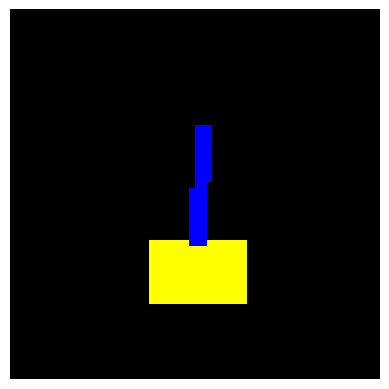

In [4]:
import matplotlib.pyplot as plt

env = MiniCartPoleVisionEnv()
obs, _ = env.reset()

plt.imshow(obs)
plt.axis('off')
plt.show()

# giving the environment actions to see movements


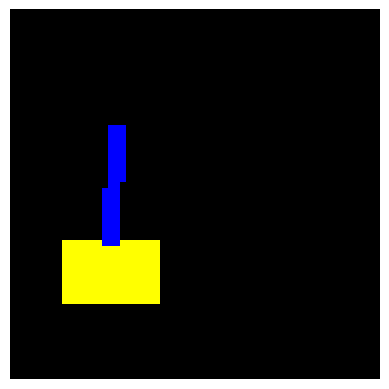

In [5]:
action = 0 #  0: move to left
obs, reward, terminated, truncated, _ = env.step(action)

plt.imshow(obs)
plt.axis('off')
plt.pause(0.1)

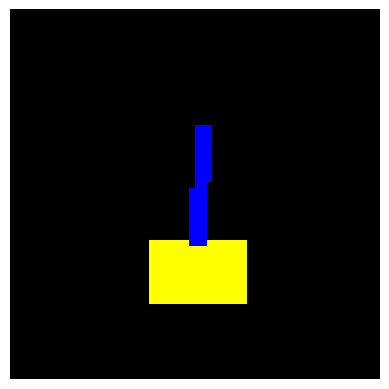

In [6]:
action = 1 # 1: Move to Right
obs, reward, terminated, truncated, _ = env.step(action)

plt.imshow(obs)
plt.axis('off')
plt.pause(0.1)

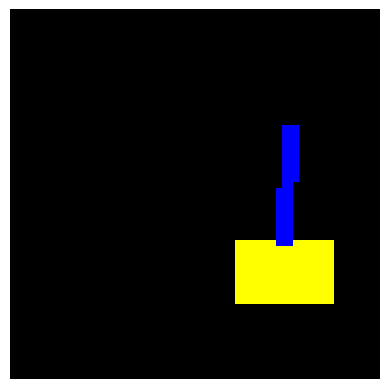

In [7]:
action = 1 # 1: Move to Right
obs, reward, terminated, truncated, _ = env.step(action)

plt.imshow(obs)
plt.axis('off')
plt.pause(0.1)

In [8]:
observations = env. observation_space.shape
print(f"The observation space has shape: {observations}")

The observation space has shape: (64, 64, 3)


In [9]:
actions = env.action_space.n
print(f"The action space has {actions} values")

The action space has 2 values


# small VLA model

1.  Vision: A small convolutional network encodes the environment’s image into a vector.
2. Language: A bag-of-words text encoder converts a human instruction into another vector.
3. Fusion + Policy Head: These vectors are concatenated and passed through a policy head to output action probabilities.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [16]:
class MiniVLA(nn.Module): #nn is a pytorhc's neural network
    def __init__(self, num_actions=2, vocab_size=1000, embed_dim=32):
        super().__init__()
        
        #vision encoder(convNet)
        self.vision = nn.Sequential(
            nn.Conv2d(3,16,3, stride=2,padding=1),
            nn.ReLU(),

            nn.Conv2d(16,32,3,stride=2, padding=1),
            nn.ReLU(),

            nn.Flatten(),
        )
        
        #vision embedding dimension after flatten
        self.vision_out = 32*16*16
        
        #language encoder(bag of words-> embedidng)
        self.text_embed = nn.Linear(vocab_size, embed_dim)
        
        #fusion+action head
        self.policy = nn.Sequential(
            nn.Linear(self.vision_out + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_actions)
        )
    
    def forward(self, image, bow_text):
        v = image/255.0
        v= v.permute(0,3,1,2)
        v=self.vision(v)
        
        t = self.text_embed(bow_text)
        
        fused= torch.cat([v,t], dim=-1)
        logits = self.policy(fused)
        action_prob =torch.softmax(logits, dim=-1)
        return action_prob

In [17]:
import torch

def make_bow_instruction(text, vocab_size=1000):
    bow = torch.zeros(vocab_size)
    for w in text.lower().split():
        idx = abs(hash(w)) % vocab_size
        bow[idx]+=1
    return bow

In [22]:
#create environment
env = MiniCartPoleVisionEnv()
obs,_ = env.reset()

#create vla
model = MiniVLA()
model.eval()

instruction = "keep the pole upright"
bow = make_bow_instruction(instruction).unsqueeze(0)

for step in range(5):
    img = torch.tensor(obs).float().unsqueeze(0)
    
    with torch.no_grad():
        action_prob = model(img,bow)
        action = torch.argmax(action_prob,dim=-1).item()
    
    obs, reward, done,truncated, info = env.step(action)
    print(f"step={step},action={action}, reward={reward:.3f}")
    
    if done:
        print("Episode ended.")
        break

step=0,action=1, reward=-0.099
step=1,action=1, reward=-0.070
step=2,action=1, reward=-0.091
step=3,action=1, reward=-0.091
step=4,action=1, reward=-0.104


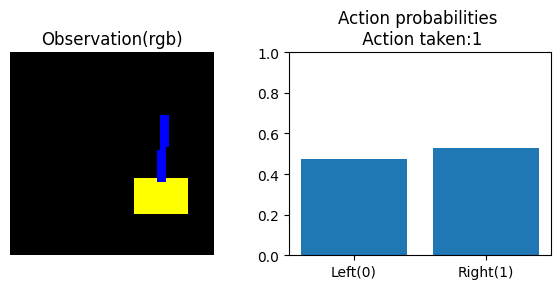

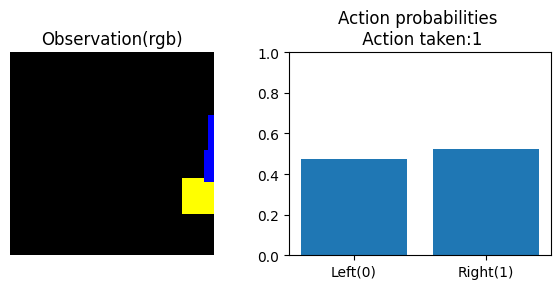

In [25]:
import matplotlib.pyplot as plt
import torch

obs, _ = env.reset()
instruction = "keep the pole upright"
bow = make_bow_instruction(instruction).unsqueeze(0)
for step in range(2):
    
    #convert observation(image) to tensor
    img_t = torch.tensor(obs).float().unsqueeze(0) #(1,H,W,3)

    #model already returns probabilities!
    with torch.no_grad():
        probs = model(img_t, bow).squeeze().numpy() #shape: (2,)
        action = int(probs.argmax())

    #environment step
    obs,reward,done,_,_ = env.step(action)

    #visualization
    plt.figure(figsize=(6,3))
    
    #IMAGE DISPLAY
    plt.subplot(1,2,1)
    plt.imshow(obs) #obs must be a uint8 RGB image
    plt.axis("off")
    plt.title("Observation(rgb)")

    #PROBABILITIES DISPLAY
    plt.subplot(1,2,2)
    plt.bar(["Left(0)", "Right(1)"], probs)
    plt.ylim(0,1)
    plt.title(f"Action probabilities \n Action taken:{action}")
    
    plt.tight_layout()
    display(plt.gcf())
    plt.close()

    if done:
        print("Episode finished.")
        break